# House Prices: Advanced Regression Techniques 
## Objective
Predict the final sale price (`SalePrice`) of residential homes in Ames, Iowa,
based on 79 explanatory variables describing almost every aspect of the property
(lot size, quality ratings, garage details, neighborhood, etc.).

## Dataset
- Source: Kaggle "House Prices: Advanced Regression Techniques" competition
- `train.csv`: 1460 rows, 81 columns (80 features + target `SalePrice`)
- `test.csv`: 1459 rows, 80 columns (no target — used for final predictions)
- `data_description.txt`: full definitions of every column and category code

## Installing XGBoost 
We download the xgboost tool. It is not built-in. We have to add it first.

In [ ]:
!pip install xgboost

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Defaulting to user installation because normal site-packages is not writeable


## Importing required libraries
We start by importing our primary tools: pandas for data tables, numpy for calculations, matplotlib for drawing charts, and XGBoost for our predictive model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

## 1. Data Ingestion ##
We load the train.csv and test.csv files into our notebook. We check how many rows and columns they have.

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f'Train set dimensions: {train.shape}')
print(f'Test set dimensions:  {test.shape}')
train.head()

Train set dimensions: (1460, 81)
Test set dimensions:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Target Variable ##
We look at house prices. We use a math tool called log1p to make the numbers smooth. This helps the computer learn easily.

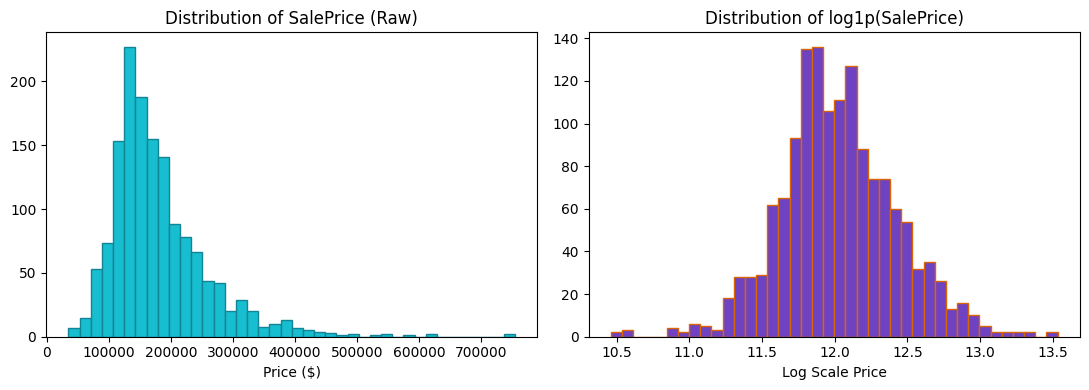

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(train['SalePrice'], bins=40, color="#cf17c3", edgecolor='#138496')
axes[0].set_title('Distribution of SalePrice (Raw)')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(train['SalePrice']), bins=40, color="#8db830", edgecolor='#d96504')
axes[1].set_title('Distribution of log1p(SalePrice)')
axes[1].set_xlabel('Log Scale Price')

plt.tight_layout()
plt.show()

## 3. Missing Value Imputation
Some empty boxes (NA) mean a house does not have that item (like no pool or no garage). Other empty boxes are just missing information.
* **Text columns for missing items:** We change NA to the word 'None'.
* **Number columns for missing items:** We change NA to the number 0.
* **Real missing information:** We fill LotFrontage with typical numbers from the same neighborhood. For text columns, we use the most common word (mode).

In [ ]:
n_train = train.shape[0]
y = np.log1p(train['SalePrice'])

all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)

none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath']
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda s: s.fillna(s.median())
)
mode_cols = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
             'Electrical', 'KitchenQual', 'Functional', 'SaleType']
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f'Total remaining missing values: {all_data.isnull().sum().sum()}')

Total remaining missing values: 0


## 4. Data Types
We change code numbers into text strings for MSSubClass. This tells the computer to treat them as normal categories.

In [ ]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)

## 5. Ordinal Encoding: Quality Ratings
We change quality words (like Poor, Good, Excellent) into ranked numbers from 0 to 5. This helps the computer understand order.

In [ ]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in quality_cols:
    all_data[col] = all_data[col].map(quality_map)

all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['GarageFinish'] = all_data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})

## 6. One-Hot Encoding: Unordered Nominal Features
Remaining text features (Neighborhood, MSZoning, SaleType, etc.) have no inherent ranking. We apply pd.get_dummies with drop_first=True to create binary indicators while avoiding multi-collinearity.

In [ ]:
all_data = pd.get_dummies(all_data, drop_first=True)

X = all_data.iloc[:n_train, :].drop('Id', axis=1)
X_test = all_data.iloc[n_train:, :].drop('Id', axis=1)

print(f'Training predictor matrix X: {X.shape}')
print(f'Test predictor matrix X_test: {X_test.shape}')

Training predictor matrix X: (1460, 228)
Test predictor matrix X_test: (1459, 228)


## 7. Splitting Data
We hide 20% of our data. We use 80% to train the model, and we use the hidden 20% to check if the model is smart.

In [ ]:
final_regressor = XGBRegressor(
    n_estimators=900,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.75,
    colsample_bytree=0.75,
    random_state=101
)
final_regressor.fit(X, y)

test_predictions = np.expm1(final_regressor.predict(X_test))


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 8. Model Training with XGBoost
Extreme Gradient Boosting (XGBoost) iteratively constructs decision trees to minimize log-scale residual errors, naturally capturing complex non-linear interactions across features.

In [ ]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

xgb.fit(X_train, y_train)

val_preds = xgb.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f'Validation RMSE (log scale): {rmse:.4f}')

Validation RMSE (log scale): 0.1306


## 9. Most Important Features(Feature Importance Analysis)
We check our trained model to find and plot the top 15 house features that matter the most for house pricing.

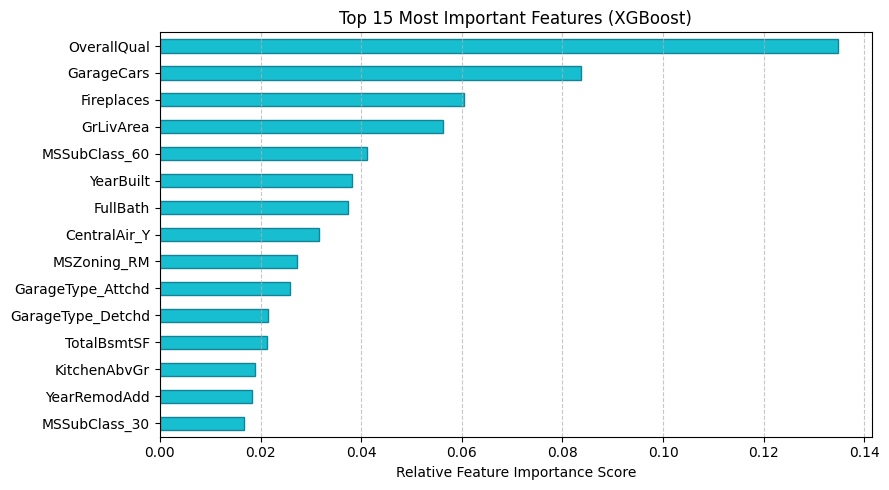

In [ ]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind='barh', color='#17becf', edgecolor='#138496')
plt.title('Top 15 Most Important Features (XGBoost)')
plt.xlabel('Relative Feature Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10. Final Predictions
We retrain our model on all data. Then, we guess prices for the test houses, fix the number scale, and save the final spreadsheet file.

In [ ]:
xgb_final = XGBRegressor(
    n_estimators=800, learning_rate=0.03, max_depth=3,
    subsample=0.7, colsample_bytree=0.7, random_state=42
).fit(X, y)

final_preds = np.expm1(xgb_final.predict(X_test))

submission = pd.DataFrame({'Id': test['Id'], 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,122807.78125
1,1462,155566.18750
2,1463,188344.50000
3,1464,188679.59375
4,1465,189498.12500
